In [ ]:
!pip -q install requests pandas matplotlib seaborn nltk sacrebleu rouge-score bert-score tqdm
!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > /tmp/ollama.log 2>&1 &
!ollama pull qwen2.5:7b

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 12.4 MB/s eta 0:00:00
>>> Installing ollama to /usr/local
ERROR: This version requires zstd for extraction. Please install zstd and try again:
  - Debian/Ubuntu: sudo apt-get install zstd
  - RHEL/CentOS/Fedora: sudo dnf install zstd
  - Arch: sudo pacman -S zstd
/bin/bash: line 1: ollama: command not found


In [ ]:
print('Installing zstd...')
!sudo apt-get update
!sudo apt-get install -y zstd
print('zstd installed successfully.')

Installing zstd...
Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Get:9 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,870 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [1,960 kB]
Get:13 http://archive.ubun

In [ ]:
print('Installing Ollama...')
!curl -fsSL https://ollama.com/install.sh | sh
print('Ollama installed successfully.')

Installing Ollama...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama installed successfully.


In [ ]:
print('Starting Ollama service...')
!nohup ollama serve > /tmp/ollama.log 2>&1 &
print('Ollama service started in the background.')

Starting Ollama service...
Ollama service started in the background.


In [ ]:
print('Pulling model qwen2.5:7b...')
!ollama pull qwen2.5:7b
print('Model qwen2.5:7b pulled.')

Pulling model qwen2.5:7b...

Model qwen2.5:7b pulled.


In [ ]:
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive")

DATASET_PATH = ".../dataset.jsonl"
from pathlib import Path
print(Path(DATASET_PATH).exists())  # Cần trả về True
OUTPUT_DIR = Path(".../qwen2_5_7b_baseline_results")

Mounted at /content/drive
True


In [ ]:
from pathlib import Path
import os
import re
import json
import time
import zipfile
import unicodedata
from collections import Counter

import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

MODEL_NAME = "qwen2.5:7b"
OLLAMA_BASE_URL = "http://localhost:11434"

# Bộ dữ liệu đã tạo trước đó.
DATASET_PATH = ".../dataset.jsonl"
DATASET_ZIP = None

# Inference
TEMPERATURE = 0.0
NUM_CTX = 8192
NUM_PREDICT = 512
REQUEST_TIMEOUT = 180
KEEP_ALIVE = "10m"

# Chạy thử trước.
SMOKE_TEST_N = 5
MAX_CASES = None  # None = toàn bộ 570 case

# Kết quả
OUTPUT_DIR = Path("./qwen2_5_7b_baseline_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_OUTPUT_PATH = OUTPUT_DIR / "raw_predictions.jsonl"
METRICS_PATH = OUTPUT_DIR / "case_metrics.jsonl"
SUMMARY_PATH = OUTPUT_DIR / "summary.json"
ERROR_PATH = OUTPUT_DIR / "errors.jsonl"

# BERTScore
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"
BERTSCORE_LANG = "en"  # see note in BERTScore cell

In [ ]:
def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Lỗi JSON tại dòng {line_no}: {exc}") from exc
    return rows

def locate_dataset():
    candidates = []

    if DATASET_PATH:
        candidates.append(Path(DATASET_PATH))

    candidates.extend([
        Path("./data/qa_test/dataset.jsonl"),
        Path("../data/qa_test/dataset.jsonl"),
        Path("./rag_test_set/dataset.jsonl"),
        Path("./dataset.jsonl"),
        Path("/mnt/data/rag_test_set/dataset.jsonl"),
    ])

    for path in candidates:
        if path.exists():
            return path

    if DATASET_ZIP and Path(DATASET_ZIP).exists():
        extract_dir = Path("./rag_tthc_qa_extracted")
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(DATASET_ZIP, "r") as z:
            if "dataset.jsonl" not in z.namelist():
                raise FileNotFoundError("ZIP không chứa dataset.jsonl")
            z.extract("dataset.jsonl", extract_dir)

        return extract_dir / "dataset.jsonl"

    raise FileNotFoundError(
        "Không tìm thấy dataset.jsonl. "
        "Hãy đặt DATASET_PATH hoặc DATASET_ZIP."
    )

dataset_file = locate_dataset()
cases = load_jsonl(dataset_file)

print("Dataset:", dataset_file)
print("Số case:", len(cases))
print("Case đầu:", cases[0]["id"])

Dataset: /content/drive/MyDrive/KHÓA LUẬN 2026 - RAG/data/qa_test/dataset.jsonl
Số case: 570
Case đầu: qa_000001


In [ ]:
# Kiểm tra các trường cần thiết
required = ["id", "question", "ground_truth"]

for i, case in enumerate(cases):
    missing = [k for k in required if k not in case]
    if "question" in case:
        missing += [k for k in ["text", "type", "difficulty"] if k not in case["question"]]
    if "ground_truth" in case:
        missing += [k for k in ["answer"] if k not in case["ground_truth"]]

    if missing:
        raise ValueError(f"Case {i} ({case.get('id')}) thiếu: {missing}")

print("Schema tối thiểu hợp lệ cho:", len(cases), "case")
print("\nQuestion type:")
print(dict(Counter(c["question"]["type"] for c in cases)))

Schema tối thiểu hợp lệ cho: 570 case

Question type:
{'metadata_identity': 120, 'procedure_step': 120, 'submission_deadline_fee': 120, 'required_documents': 120, 'multi_hop_metadata_operation': 40, 'unanswerable_missing_field': 50}


In [ ]:
def ollama_chat_question(question: str):
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "user",
                "content": question
            }
        ],
        "stream": False,
        "options": {
            "temperature": TEMPERATURE,
            "num_ctx": NUM_CTX,
            "num_predict": NUM_PREDICT,
        },
        "keep_alive": KEEP_ALIVE,
    }

    response = requests.post(
        f"{OLLAMA_BASE_URL}/api/chat",
        json=payload,
        timeout=REQUEST_TIMEOUT,
    )
    response.raise_for_status()
    data = response.json()

    answer = (
        data.get("message", {}).get("content", "")
        or data.get("response", "")
        or ""
    ).strip()

    return answer, data

def check_ollama():
    response = requests.get(
        f"{OLLAMA_BASE_URL}/api/tags",
        timeout=20,
    )
    response.raise_for_status()

    models = [
        model.get("name")
        for model in response.json().get("models", [])
    ]

    print("Ollama models:", models)

    if MODEL_NAME not in models:
        raise RuntimeError(
            f"Chưa có {MODEL_NAME}. Chạy: ollama pull {MODEL_NAME}"
        )

check_ollama()

Ollama models: ['qwen2.5:7b']


In [ ]:
smoke_rows = []

for case in cases[:min(SMOKE_TEST_N, len(cases))]:
    start = time.perf_counter()

    try:
        answer, raw = ollama_chat_question(case["question"]["text"])
        elapsed = time.perf_counter() - start

        smoke_rows.append({
            "id": case["id"],
            "question": case["question"]["text"],
            "ground_truth": case["ground_truth"]["answer"],
            "prediction": answer,
            "latency_s": round(elapsed, 2),
        })
    except Exception as exc:
        smoke_rows.append({
            "id": case["id"],
            "question": case["question"]["text"],
            "ground_truth": case["ground_truth"]["answer"],
            "prediction": f"ERROR: {exc}",
            "latency_s": None,
        })

display(pd.DataFrame(smoke_rows))

,id,question,ground_truth,prediction,latency_s
0,qa_000001,Thủ tục hành chính “Thủ tục hải quan đối với k...,Mã thủ tục: 1.000005. Lĩnh vực: Hải quan.,"Thủ tục hành chính ""Thủ tục hải quan đối với k...",111.83
1,qa_000002,"Trong thủ tục “Thủ tục hải quan đối với khí, n...",Doanh nghiệp gửi hồ sơ đề nghị làm thủ tục hải...,"Trong thủ tục hải quan đối với khí, nguyên liệ...",9.76
2,qa_000003,"Thủ tục “Thủ tục hải quan đối với khí, nguyên ...",Hình thức nộp: Trực tuyến; Thời hạn giải quyết...,"Theo quy định của Tổng cục Hải quan Việt Nam, ...",5.19
3,qa_000004,Hồ sơ của thủ tục “Thủ tục hải quan đối với kh...,Các nội dung hồ sơ được ghi nhận gồm:\n- 1. Ch...,"Thủ tục hải quan đối với khí, nguyên liệu xuất...",13.09
4,qa_000005,"Thủ tục hành chính “Đánh giá, chứng nhận năng ...",Mã thủ tục: 1.000010. Lĩnh vực: Đăng kiểm.,"Thủ tục hành chính ""Đánh giá, chứng nhận năng ...",4.95


In [ ]:
def normalize_answer(text: str) -> str:
    if text is None:
        return ""

    text = unicodedata.normalize("NFC", str(text)).lower().strip()
    text = re.sub(r'[“”"`]', "", text)
    text = re.sub(r"[.,;:!?()\[\]{}]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def exact_match(prediction: str, reference: str) -> int:
    return int(str(prediction).strip() == str(reference).strip())

def normalized_accuracy(prediction: str, reference: str) -> int:
    return int(
        normalize_answer(prediction) ==
        normalize_answer(reference)
    )

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def bleu_score(prediction: str, reference: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    ref_tokens = normalize_answer(reference).split()

    if not pred_tokens or not ref_tokens:
        return 0.0

    # BLEU-4 với smoothing để tránh quá nhiều case bằng 0 ở câu ngắn.
    return float(
        sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth,
        )
    )

In [ ]:
from rouge_score import rouge_scorer

rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False,
)

def rouge_scores(prediction: str, reference: str):
    result = rouge.score(
        normalize_answer(reference),
        normalize_answer(prediction),
    )

    return {
        "rouge1_f1": float(result["rouge1"].fmeasure),
        "rouge2_f1": float(result["rouge2"].fmeasure),
        "rougeL_f1": float(result["rougeL"].fmeasure),
    }

In [ ]:
from bert_score import score as bertscore_score

# Gợi ý: thay bằng encoder multilingual phù hợp với môi trường của bạn.
# Có thể thử "xlm-roberta-large" nếu máy đủ tài nguyên.
BERTSCORE_MODEL = "xlm-roberta-large"

def compute_bertscore(predictions, references):
    P, R, F1 = bertscore_score(
        predictions,
        references,
        model_type=BERTSCORE_MODEL,
        lang=None,
        batch_size=4,
        rescale_with_baseline=False,
        verbose=True,
    )

    return (
        [float(x) for x in P],
        [float(x) for x in R],
        [float(x) for x in F1],
    )

In [ ]:
def load_jsonl_if_exists(path: Path):
    if not path.exists():
        return []

    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except Exception:
                    pass
    return rows

def append_jsonl(path: Path, obj):
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

existing = {
    row["id"]
    for row in load_jsonl_if_exists(RAW_OUTPUT_PATH)
    if row.get("id")
}

selected_cases = cases if MAX_CASES is None else cases[:MAX_CASES]
pending = [case for case in selected_cases if case["id"] not in existing]

print("Tổng case:", len(selected_cases))
print("Đã có output:", len(existing))
print("Cần chạy:", len(pending))

for case in tqdm(pending, desc=f"Running {MODEL_NAME}"):
    start = time.perf_counter()

    try:
        answer, raw = ollama_chat_question(case["question"]["text"])
        elapsed = time.perf_counter() - start

        append_jsonl(RAW_OUTPUT_PATH, {
            "id": case["id"],
            "model": MODEL_NAME,
            "question": case["question"]["text"],
            "ground_truth": case["ground_truth"]["answer"],
            "prediction": answer,
            "latency_s": elapsed,
            "temperature": TEMPERATURE,
            "num_ctx": NUM_CTX,
            "num_predict": NUM_PREDICT,
            "raw_ollama": raw,
        })

    except Exception as exc:
        append_jsonl(ERROR_PATH, {
            "id": case["id"],
            "error": repr(exc),
        })

Tổng case: 570
Đã có output: 0
Cần chạy: 570


Running qwen2.5:7b:   0%|          | 0/570 [00:00<?, ?it/s]

In [ ]:
prediction_rows = load_jsonl_if_exists(RAW_OUTPUT_PATH)
pred_df = pd.DataFrame(prediction_rows)

print("Predictions:", len(pred_df))

if pred_df.empty:
    raise RuntimeError("Chưa có prediction. Hãy chạy inference cell trước.")

metric_rows = []

for row in pred_df.to_dict(orient="records"):
    pred = row.get("prediction", "")
    ref = row.get("ground_truth", "")

    r = rouge_scores(pred, ref)

    metric_rows.append({
        "id": row["id"],
        "model": row["model"],
        "question": row["question"],
        "ground_truth": ref,
        "prediction": pred,
        "exact_match_raw": exact_match(pred, ref),
        "accuracy_normalized": normalized_accuracy(pred, ref),
        "bleu4": bleu_score(pred, ref),
        "rouge1_f1": r["rouge1_f1"],
        "rouge2_f1": r["rouge2_f1"],
        "rougeL_f1": r["rougeL_f1"],
        "latency_s": row.get("latency_s"),
    })

metrics_df = pd.DataFrame(metric_rows)

display(
    metrics_df[
        [
            "id",
            "accuracy_normalized",
            "bleu4",
            "rougeL_f1",
            "prediction",
            "ground_truth",
        ]
    ].head(20)
)

Predictions: 570


,id,accuracy_normalized,bleu4,rougeL_f1,prediction,ground_truth
0,qa_000001,0,0.022948,0.096916,"Thủ tục hành chính ""Thủ tục hải quan đối với k...",Mã thủ tục: 1.000005. Lĩnh vực: Hải quan.
1,qa_000002,0,0.061689,0.135246,"Trong thủ tục hải quan đối với khí, nguyên liệ...",Doanh nghiệp gửi hồ sơ đề nghị làm thủ tục hải...
2,qa_000003,0,0.027256,0.181070,"Theo quy định của Tổng cục Hải quan Việt Nam, ...",Hình thức nộp: Trực tuyến; Thời hạn giải quyết...
3,qa_000004,0,0.030995,0.288089,"Thủ tục hải quan đối với khí, nguyên liệu xuất...",Các nội dung hồ sơ được ghi nhận gồm:\n- 1. Ch...
4,qa_000005,0,0.009207,0.096916,"Thủ tục hành chính ""Đánh giá, chứng nhận năng ...",Mã thủ tục: 1.000010. Lĩnh vực: Đăng kiểm.
5,qa_000006,0,0.030095,0.301918,"Trong hồ sơ dữ liệu của thủ tục ""Đánh giá, chứ...","Tổ chức, cá nhân hoàn thiện 01 (một) bộ hồ sơ ..."
6,qa_000007,0,0.008750,0.144981,"Dựa trên thông tin bạn cung cấp, tôi sẽ cố gắn...","Hình thức nộp | Thời hạn giải | quyết | Phí, l..."
7,qa_000008,0,0.003644,0.234637,"Thủ tục đánh giá, chứng nhận năng lực cơ sở th...",Các nội dung hồ sơ được ghi nhận gồm:\n- - 01 ...
8,qa_000009,0,0.025508,0.107317,"Thủ tục hành chính ""Thủ tục hải quan đối với x...",Mã thủ tục: 1.000014. Lĩnh vực: Hải quan.
9,qa_000010,0,0.030040,0.157791,"Trong thủ tục hải quan đối với xăng dầu, hóa c...",Doanh nghiệp gửi hồ sơ cho Chi cục Hải quan nơ...


In [ ]:
predictions = metrics_df["prediction"].fillna("").tolist()
references = metrics_df["ground_truth"].fillna("").tolist()

P, R, F1 = compute_bertscore(predictions, references)

metrics_df["bertscore_precision"] = P
metrics_df["bertscore_recall"] = R
metrics_df["bertscore_f1"] = F1

metrics_df.to_json(
    METRICS_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Đã tính BERTScore cho", len(metrics_df), "case.")

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

calculating scores...
computing bert embedding.


  0%|          | 0/268 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/143 [00:00<?, ?it/s]

done in 51.60 seconds, 11.05 sentences/sec
Đã tính BERTScore cho 570 case.


In [ ]:
meta_df = pd.DataFrame([
    {
        "id": case["id"],
        "question_type": case["question"]["type"],
        "difficulty": case["question"]["difficulty"],
        "answerability": case["question"].get("answerability"),
    }
    for case in selected_cases
])

metrics_df = metrics_df.merge(meta_df, on="id", how="left")

display(
    metrics_df.groupby("question_type")[
        [
            "accuracy_normalized",
            "bleu4",
            "rouge1_f1",
            "rouge2_f1",
            "rougeL_f1",
            "bertscore_f1",
        ]
    ]
    .mean()
    .sort_values("accuracy_normalized")
)

,accuracy_normalized,bleu4,rouge1_f1,rouge2_f1,rougeL_f1,bertscore_f1
question_type,,,,,,
metadata_identity,0.0,0.018492,0.143672,0.098293,0.128851,0.854395
multi_hop_metadata_operation,0.0,0.029164,0.350529,0.157150,0.231429,0.830205
procedure_step,0.0,0.069663,0.487365,0.250685,0.275156,0.853203
required_documents,0.0,0.067584,0.498967,0.240786,0.279638,0.842313
submission_deadline_fee,0.0,0.037874,0.390548,0.206881,0.260663,0.840237
unanswerable_missing_field,0.0,0.084192,0.235769,0.186877,0.224099,0.881118


In [ ]:
summary = {
    "model": MODEL_NAME,
    "n_cases": int(len(metrics_df)),
    "accuracy_exact_match_raw": float(metrics_df["exact_match_raw"].mean()),
    "accuracy_normalized": float(metrics_df["accuracy_normalized"].mean()),
    "bleu4": float(metrics_df["bleu4"].mean()),
    "rouge1_f1": float(metrics_df["rouge1_f1"].mean()),
    "rouge2_f1": float(metrics_df["rouge2_f1"].mean()),
    "rougeL_f1": float(metrics_df["rougeL_f1"].mean()),
    "bertscore_precision": float(metrics_df["bertscore_precision"].mean()),
    "bertscore_recall": float(metrics_df["bertscore_recall"].mean()),
    "bertscore_f1": float(metrics_df["bertscore_f1"].mean()),
    "mean_latency_s": float(metrics_df["latency_s"].mean()),
    "p50_latency_s": float(metrics_df["latency_s"].median()),
}

SUMMARY_PATH.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "model": "qwen2.5:7b",
  "n_cases": 570,
  "accuracy_exact_match_raw": 0.0,
  "accuracy_normalized": 0.0,
  "bleu4": 0.050192434381793216,
  "rouge1_f1": 0.3653959727032554,
  "rouge2_f1": 0.19513569215998683,
  "rougeL_f1": 0.23469993532448946,
  "bertscore_precision": 0.8299345906366382,
  "bertscore_recall": 0.8707199200203545,
  "bertscore_f1": 0.8492663299828245,
  "mean_latency_s": 10.354991249582449,
  "p50_latency_s": 9.902612876499916
}


In [ ]:
print("=== THEO QUESTION TYPE ===")
type_report = (
    metrics_df
    .groupby("question_type")[
        [
            "accuracy_normalized",
            "bleu4",
            "rougeL_f1",
            "bertscore_f1",
            "latency_s",
        ]
    ]
    .mean()
    .sort_values("accuracy_normalized")
)

display(type_report)

print("\n=== THEO DIFFICULTY ===")
difficulty_report = (
    metrics_df
    .groupby("difficulty")[
        [
            "accuracy_normalized",
            "bleu4",
            "rougeL_f1",
            "bertscore_f1",
            "latency_s",
        ]
    ]
    .mean()
    .sort_values("accuracy_normalized")
)

display(difficulty_report)

=== THEO QUESTION TYPE ===


,accuracy_normalized,bleu4,rougeL_f1,bertscore_f1,latency_s
question_type,,,,,
metadata_identity,0.0,0.018492,0.128851,0.854395,6.348140
multi_hop_metadata_operation,0.0,0.029164,0.231429,0.830205,12.705502
procedure_step,0.0,0.069663,0.275156,0.853203,12.401353
required_documents,0.0,0.067584,0.279638,0.842313,14.381628
submission_deadline_fee,0.0,0.037874,0.260663,0.840237,9.423069
unanswerable_missing_field,0.0,0.084192,0.224099,0.881118,5.752441



=== THEO DIFFICULTY ===


,accuracy_normalized,bleu4,rougeL_f1,bertscore_f1,latency_s
difficulty,,,,,
easy,0.0,0.018492,0.128851,0.854395,6.348140
hard,0.0,0.059735,0.227357,0.858490,8.842690
medium,0.0,0.058374,0.271819,0.845251,12.068683


In [ ]:
wrong = metrics_df[
    metrics_df["accuracy_normalized"] == 0
].copy()

display(
    wrong.sort_values("bertscore_f1", ascending=False)[
        [
            "id",
            "question_type",
            "question",
            "ground_truth",
            "prediction",
            "bleu4",
            "rougeL_f1",
            "bertscore_f1",
        ]
    ].head(30)
)

,id,question_type,question,ground_truth,prediction,bleu4,rougeL_f1,bertscore_f1
528,qa_000529,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng thông tin về số điện thoại cụ t...",0.119655,0.327485,0.896825
526,qa_000527,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.131491,0.321839,0.896220
540,qa_000541,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.129513,0.315789,0.894669
550,qa_000551,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.109351,0.276190,0.894553
524,qa_000525,unanswerable_missing_field,Email cá nhân của chuyên viên phụ trách thủ tụ...,Không có thông tin về email cá nhân của chuyên...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.111581,0.290698,0.893655
543,qa_000544,unanswerable_missing_field,Email cá nhân của chuyên viên phụ trách thủ tụ...,Không có thông tin về email cá nhân của chuyên...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.129797,0.297619,0.892688
531,qa_000532,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.130085,0.335196,0.890478
561,qa_000562,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.095753,0.241935,0.890476
545,qa_000546,unanswerable_missing_field,Số điện thoại của cán bộ trực tiếp xử lý thủ t...,Không có thông tin về số điện thoại của cán bộ...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.101491,0.248963,0.890017
546,qa_000547,unanswerable_missing_field,Email cá nhân của chuyên viên phụ trách thủ tụ...,Không có thông tin về email cá nhân của chuyên...,"Xin lỗi, nhưng tôi không có thông tin cụ thể v...",0.109168,0.305085,0.889364


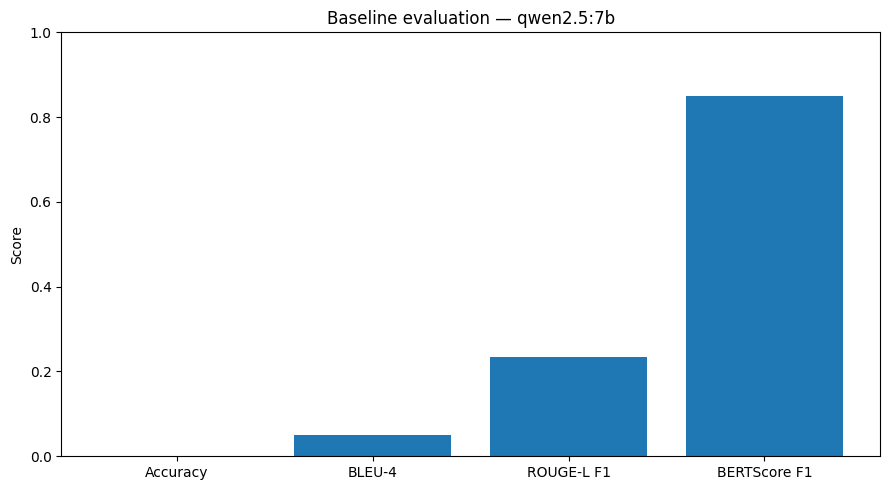

In [ ]:
report = summary

plt.figure(figsize=(9, 5))
metric_names = ["Accuracy", "BLEU-4", "ROUGE-L F1", "BERTScore F1"]
metric_values = [
    report["accuracy_normalized"],
    report["bleu4"],
    report["rougeL_f1"],
    report["bertscore_f1"],
]

plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title(f"Baseline evaluation — {MODEL_NAME}")
plt.tight_layout()
plt.show()

In [ ]:
metrics_df.to_csv(
    OUTPUT_DIR / "case_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

summary_table = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Accuracy": summary["accuracy_normalized"],
    "BLEU-4": summary["bleu4"],
    "ROUGE-L F1": summary["rougeL_f1"],
    "BERTScore F1": summary["bertscore_f1"],
    "Mean latency (s)": summary["mean_latency_s"],
}])

display(summary_table)

,Model,Accuracy,BLEU-4,ROUGE-L F1,BERTScore F1,Mean latency (s)
0,qwen2.5:7b,0.0,0.050192,0.2347,0.849266,10.354991


### 2\. Phân tích kết quả

* **Accuracy = 0.0 (0%):**
  * **Ý nghĩa:** Mô hình gốc không trả lời chính xác được câu nào theo các tiêu chí khớp tuyệt đối hoặc đáp ứng đầy đủ các ý bắt buộc (*must\_include / key\_points*).
  * **Thực trạng:** Tri thức nội tại (parametric knowledge) của mô hình gốc không chứa các thông tin cụ thể, chính xác về quy trình, mã thủ tục, phí/lệ phí hay thời hạn giải quyết của thủ tục hành chính công Việt Nam.
* **BLEU-4 = 0.0502 (5.02%):**
  * **Ý nghĩa:** Chỉ số đo độ trùng khớp cụm 4 từ (*n-gram*) cực kỳ thấp.
  * **Thực trạng:** Câu trả lời sinh ra từ mô hình gốc hầu như không chứa các cụm từ vựng hành chính chuẩn xác đúng theo văn bản quy phạm pháp luật hoặc đáp án chuẩn (*ground truth*).
* **ROUGE-L F1 = 0.2347 (23.47%):**
  * **Ý nghĩa:** Đo độ bao phủ chuỗi con chung dài nhất (*Longest Common Subsequence*).
  * **Thực trạng:** Mức điểm \~23.5% phản ánh văn bản do mô hình tự sinh có sự tương đồng ở một số từ nối hoặc mẫu câu giao tiếp tiếng Việt chung chung, nhưng thiếu hẳn cấu trúc và các ý chính chuyên ngành cần thiết.
* **BERTScore F1 = 0.8493 (84.93%) —** **Hiện tượng đáng chú ý** **:**
  * **Ý nghĩa:** BERTScore đo sự tương đồng về ngữ nghĩa ở mức ngữ cảnh (*contextual embedding similarity*).
  * **Thực trạng:** Dù Accuracy bằng 0 và BLEU rất thấp, BERTScore lại đạt mức khá cao (\~84.9%). Nguyên nhân là do mô hình **Qwen2.5:7b** có khả năng hiểu và biểu diễn ngữ nghĩa tiếng Việt tốt, sinh ra câu văn trôi chảy, đúng định dạng tư vấn/trả lời câu hỏi. Tuy nhiên, **sự tương đồng về mặt văn phong/ngữ nghĩa hình thức không đồng nghĩa với tính chính xác về mặt pháp lý và dữ kiện (** **factual correctness** **)**.
* **Mean Latency = 10.35 giây:**
  * **Ý nghĩa:** Thời gian phản hồi trung bình khoảng 10.35s/câu hỏi khi chạy suy luận trực tiếp (*direct inference*). Đây là mốc thời gian cơ sở của mô hình 7B khi chưa tốn chi phí tính toán cho việc truy hồi tài liệu (Retrieval) hoặc xử lý Context dài từ RAG.

---

### 3\. Đánh giá tổng thể &amp; Nguyên nhân

1. **Hạn chế về tri thức miền (Domain Knowledge Gap):** Mô hình `qwen2.5:7b` dù là một mô hình ngôn ngữ lớn đa ngôn ngữ mạnh mẽ, nhưng ở dạng gốc (*zero-shot/direct prompt*), nó mắc phải hiện tượng "bị ảo giác" (*hallucination*) hoặc đưa ra câu trả lời chung chung do không nắm được dữ liệu quy định cụ thể của hành chính công Việt Nam.
2. **Giá trị mốc cơ sở (Baseline):** Kết quả này phản ánh đúng thực trạng của một LLM chưa qua tối ưu chuyên biệt, tạo ra một **mốc đối chứng độ chênh lệch (gap) rất rõ ràng** để đo lường hiệu quả của các giải pháp cải tiến tiếp theo trong đề tà